# Demo 3: Interpretability of SigmaSelector

Analyze how the SigmaSelector routes LocationEncoder branches across different
$\sigma$ (frequency scales).

**Architecture note:** SigmaSelector takes _geographic coordinates_ as input
(via Equal Earth projection), not image features. It learns a spatial prior --
certain regions of the globe benefit more from fine-grained vs. coarse-grained
positional encodings. This is useful for understanding latitude-dependent
distortion patterns.

We compare urban vs. natural regions to see if the model has learned different
routing strategies for different parts of the world.

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

_root = Path.cwd().parent if Path.cwd().name == 'demos' else Path.cwd()
sys.path.insert(0, str(_root))

from demos.demo_utils import load_geotx_model, STREETVIEW_CSV, STREETVIEW_IMAGES
from geoclip.train.dataloader import img_val_transform

%matplotlib inline

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = load_geotx_model(device)

# Sigma values from the LocationEncoder
sigmas = model.location_encoder.sigma  # [2^0, 2^4, 2^8] = [1, 16, 256]
print(f'Sigma values: {sigmas}')
print(f'SigmaSelector enabled: {model.location_encoder.use_sigma_selector}')

Loading GeoCLIP:  20%|██        | 1/5 [00:14<00:59, 14.90s/step, Build model (CLIP from config, no HF download)]

LoRA applied to CLIP ViT layers 18-23 (r=4, alpha=8, dropout=0.05, targets=['v_proj', 'q_proj'])


Loading GeoCLIP: 100%|██████████| 5/5 [00:43<00:00,  8.68s/step, Done]                                          

GeoTX model loaded on cuda (queue_size=2048, lora_r=4, lora_alpha=8)
Sigma values: [1, 16, 256]
SigmaSelector enabled: True


In [3]:
# --- Curated example selection ---
# Two ways to add images:
#   1. Region bounding boxes (auto-samples from the CSV within lat/lon bounds)
#   2. Manual filenames     (exact IMG_FILE entries from the CSV)

df_all = pd.read_csv(STREETVIEW_CSV)

# ── Region-based sampling ────────────────────────────────────────────────────
URBAN_REGIONS = {}

NATURAL_REGIONS = {
    'Iceland': (63.5, 66.5, -23.0, -13.0),
    'Patagonia (Argentina)': (-52.0, -48.0, -74.0, -68.0),
    'Scottish Highlands': (56.5, 58.5, -5.5, -3.0),
}

# ── Manual filename-based selection ──────────────────────────────────────────
# Add exact IMG_FILE names from the CSV to guarantee specific images appear.
MANUAL_URBAN = [
    "streetview_00000008.jpg", # Singapore
    "streetview_00000017.jpg", # South Korea
    "streetview_00000091.jpg", # Hong Kong, China
    "streetview_00000096.jpg",
    "streetview_00000115.jpg",
    "streetview_00000130.jpg",
    "streetview_00000131.jpg",
    "streetview_00001076.jpg",
    "streetview_00001123.jpg",
    "streetview_00001596.jpg",
    "streetview_00002395.jpg",
    "streetview_00003377.jpg",
]

MANUAL_NATURAL = [
    "streetview_00000000.jpg",
    "streetview_00000034.jpg",
]

# ── Sampling logic ───────────────────────────────────────────────────────────

def _filename_to_sample(name, fname):
    """Look up a CSV filename and return a sample dict, or None if not found."""
    row = df_all[df_all['IMG_FILE'] == fname]
    if len(row) == 0:
        print(f'  Warning: filename not found in CSV: {fname}')
        return None
    return {
        'name': name,
        'image_file': fname,
        'lat': float(row.iloc[0]['LAT']),
        'lon': float(row.iloc[0]['LON']),
    }

def sample_images_for_regions(region_dict, category, n_per_region=6, seed=42):
    rng = np.random.RandomState(seed)
    samples = []
    for name, (lat_lo, lat_hi, lon_lo, lon_hi) in region_dict.items():
        mask = (
            (df_all['LAT'] >= lat_lo) & (df_all['LAT'] <= lat_hi)
            & (df_all['LON'] >= lon_lo) & (df_all['LON'] <= lon_hi)
        )
        region_df = df_all[mask]
        if len(region_df) == 0:
            print(f'  Warning: no images found in {name}')
            continue
        n_sample = min(n_per_region, len(region_df))
        idx = rng.choice(region_df.index, n_sample, replace=False)
        for i in idx:
            samples.append({
                'name': name,
                'category': category,
                'image_file': region_df.loc[i, 'IMG_FILE'],
                'lat': region_df.loc[i, 'LAT'],
                'lon': region_df.loc[i, 'LON'],
            })
    return samples

# Collect samples from both sources
urban_samples = sample_images_for_regions(URBAN_REGIONS, 'urban')
natural_samples = sample_images_for_regions(NATURAL_REGIONS, 'natural')

for fname in MANUAL_URBAN:
    s = _filename_to_sample('Manual Urban', fname)
    if s:
        s['category'] = 'urban'
        urban_samples.append(s)

for fname in MANUAL_NATURAL:
    s = _filename_to_sample('Manual Natural', fname)
    if s:
        s['category'] = 'natural'
        natural_samples.append(s)

all_samples = urban_samples + natural_samples

print(f'Selected {len(urban_samples)} urban + {len(natural_samples)} natural = {len(all_samples)} images')

Selected 12 urban + 20 natural = 32 images


In [4]:
# --- Extract SigmaSelector weights for each image ---
transform = img_val_transform()

results = []
for sample in all_samples:
    img_path = STREETVIEW_IMAGES / sample['image_file']
    if not img_path.exists():
        print(f'  Missing: {img_path}')
        continue
    
    # Preprocess image
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # GPS for the image (SigmaSelector takes GPS as input)
    gps = torch.tensor([[sample['lat'], sample['lon']]], dtype=torch.float32).to(device)
    
    # Get sigma weights
    with torch.no_grad():
        weights = model.location_encoder.get_sigma_weights(gps).cpu().numpy().flatten()
    
    results.append({
        **sample,
        'image': img,
        'weights': weights,
    })

print(f'Extracted weights for {len(results)} images')

Extracted weights for 32 images


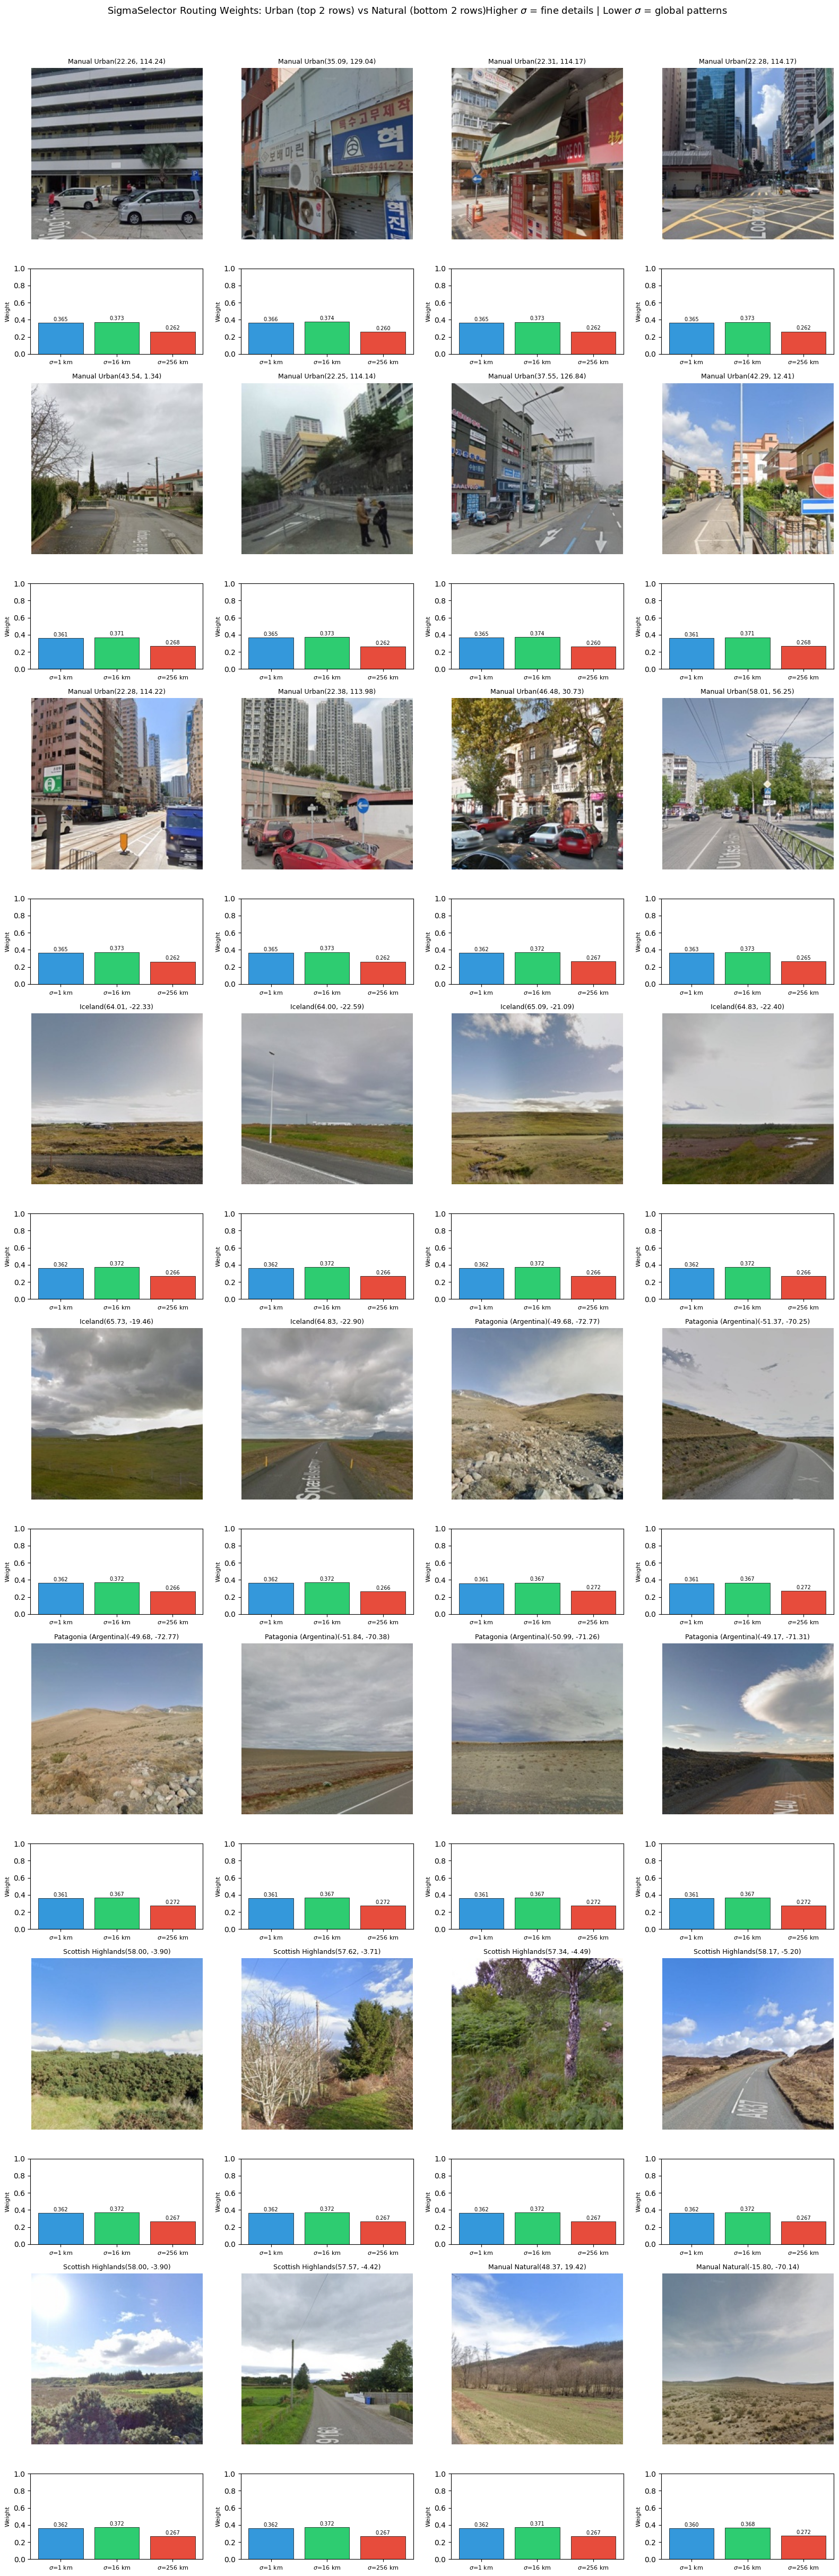

In [6]:
# --- Side-by-side visualization ---
n_cols = 4
n_rows = (len(results) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows * 2, n_cols,
    figsize=(n_cols * 4, n_rows * 6),
    gridspec_kw={'height_ratios': [2, 1] * n_rows},
)

sigma_labels = [f'$\\sigma$={s} km' for s in sigmas]
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, res in enumerate(results):
    row = (idx // n_cols) * 2
    col = idx % n_cols

    ax_img = axes[row, col] if n_rows > 1 else axes[col]
    ax_bar = axes[row + 1, col] if n_rows > 1 else axes[col]

    # Show image
    ax_img.imshow(res['image'])
    img_title = res['name'] + '' + f'({res["lat"]:.2f}, {res["lon"]:.2f})'
    ax_img.set_title(img_title, fontsize=9)
    ax_img.axis('off')

    # Show bar chart of sigma weights
    bars = ax_bar.bar(range(len(sigmas)), res['weights'], color=colors, edgecolor='black', linewidth=0.5)
    ax_bar.set_xticks(range(len(sigmas)))
    ax_bar.set_xticklabels(sigma_labels, fontsize=8)
    ax_bar.set_ylim(0, 1.0)
    ax_bar.set_ylabel('Weight', fontsize=8)

    # Annotate bar values
    for bar, w in zip(bars, res['weights']):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{w:.3f}', ha='center', fontsize=7)

# Hide unused axes
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else np.atleast_1d(axes)
for j in range(len(results) * 2, len(axes_flat)):
    axes_flat[j].axis('off')

suptitle_line1 = 'SigmaSelector Routing Weights: Urban (top 2 rows) vs Natural (bottom 2 rows)'
suptitle_line2 = 'Higher $\\sigma$ = fine details | Lower $\\sigma$ = global patterns'
fig.suptitle(suptitle_line1 + '' + suptitle_line2, fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

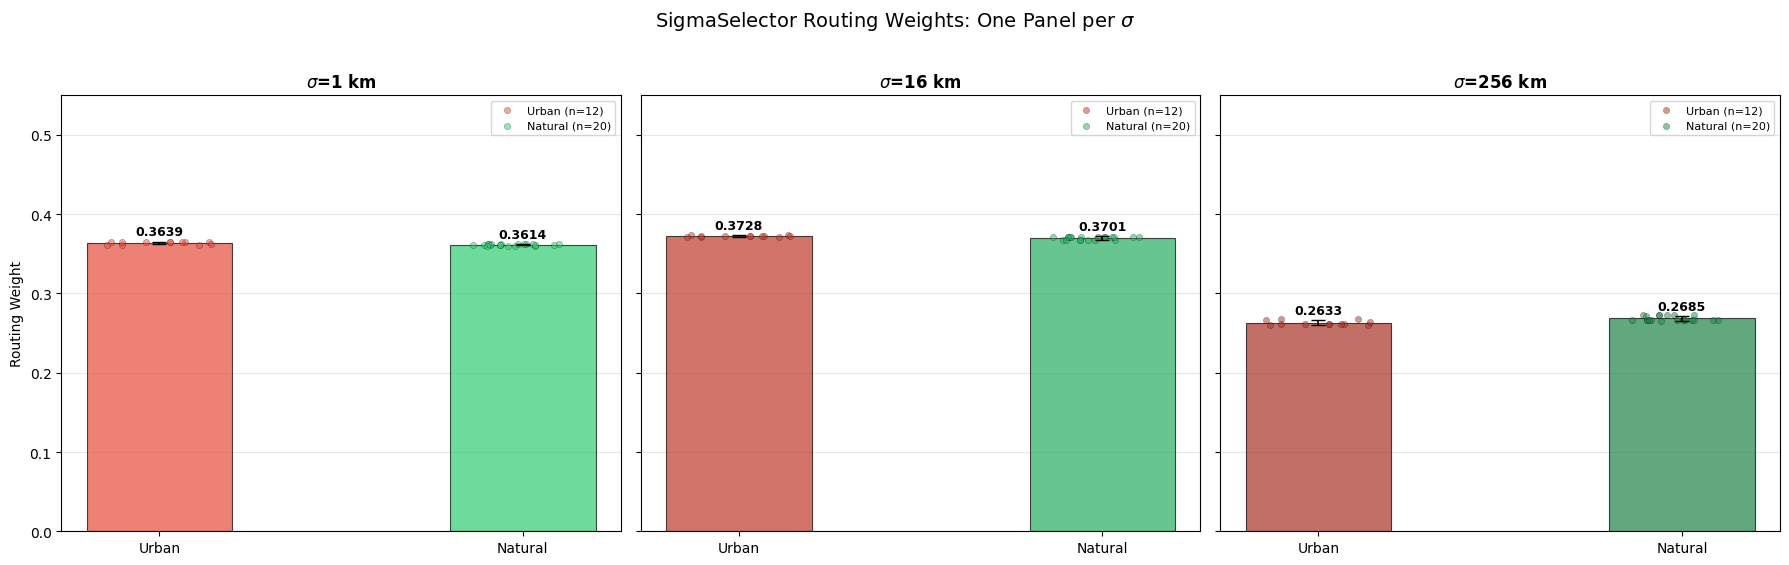

In [7]:
# --- One plot per sigma: urban vs natural weight distributions ---
urban_weights = np.array([r['weights'] for r in results if r['category'] == 'urban'])
natural_weights = np.array([r['weights'] for r in results if r['category'] == 'natural'])

sigma_labels = [f'$\\sigma$={s} km' for s in sigmas]
colors_urban = ['#e74c3c', '#c0392b', '#a93226']
colors_natural = ['#2ecc71', '#27ae60', '#1e8449']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for i, ax in enumerate(axes):
    # Jittered scatter for individual samples
    rng = np.random.RandomState(42)
    if len(urban_weights) > 0:
        jitter = rng.uniform(-0.15, 0.15, len(urban_weights))
        ax.scatter(np.full_like(jitter, 0) + jitter, urban_weights[:, i],
                   alpha=0.5, s=20, color=colors_urban[i], edgecolors='black',
                   linewidth=0.3, label=f'Urban (n={len(urban_weights)})', zorder=3)
    if len(natural_weights) > 0:
        jitter = rng.uniform(-0.15, 0.15, len(natural_weights))
        ax.scatter(np.full_like(jitter, 1) + jitter, natural_weights[:, i],
                   alpha=0.5, s=20, color=colors_natural[i], edgecolors='black',
                   linewidth=0.3, label=f'Natural (n={len(natural_weights)})', zorder=3)

    # Mean + error bar for each category
    positions = [0, 1]
    means = []
    stds = []
    if len(urban_weights) > 0:
        means.append(urban_weights[:, i].mean())
        stds.append(urban_weights[:, i].std())
    if len(natural_weights) > 0:
        means.append(natural_weights[:, i].mean())
        stds.append(natural_weights[:, i].std())

    bar_colors = []
    if len(urban_weights) > 0:
        bar_colors.append(colors_urban[i])
    if len(natural_weights) > 0:
        bar_colors.append(colors_natural[i])

    bars = ax.bar(positions, means, 0.4, color=bar_colors, edgecolor='black',
                  linewidth=0.8, alpha=0.7, zorder=2)
    ax.errorbar(positions, means, yerr=stds, fmt='none', ecolor='black',
                capsize=5, linewidth=1.2, zorder=4)

    # Annotate mean values on bars
    for bar, mean_val, std_val in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std_val + 0.008,
                f'{mean_val:.4f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(positions)
    ax.set_xticklabels(['Urban', 'Natural'], fontsize=10)
    ax.set_ylim(0, max(0.55, max(means) + max(stds) + 0.06))
    ax.set_ylabel('Routing Weight' if i == 0 else '', fontsize=10)
    ax.set_title(f'{sigma_labels[i]}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('SigmaSelector Routing Weights: One Panel per $\\sigma$',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()